In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Set up matplotlib defaults for consistent plots
plt.rcParams['figure.figsize'] = (10, 6)  # Standard figure size
plt.rcParams['figure.dpi'] = 100  # Standard resolution

# Font sizes
plt.rcParams['font.size'] = 16  # Base font size
plt.rcParams['axes.titlesize'] = 22  # Plot title
plt.rcParams['axes.labelsize'] = 18  # Axis labels
plt.rcParams['xtick.labelsize'] = 16  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 16  # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 18  # Legend text

# Line and marker styles
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8

# Grid settings
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Legend settings
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'gray'

# Save figure settings
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.2

In [ ]:
import jax.numpy as np
import jax.random as random



n = 1_000_000

key = random.PRNGKey(0)

original_sample = random.normal(key, shape=(n,))
print("done generating samples")
data = original_sample * 0.5 + 0.5
data2 = data + 0.1

data_bounded = np.clip(data, -1, 1)
data_bounded2 = np.clip(data2, -1, 1)

print("done clipping")

data_tanh = np.tanh(data)
data_tanh2 = np.tanh(data2)

print("done bounding samples")

# Use a seaborn color palette for improved aesthetics
palette = sns.color_palette("viridis", 3)

plt.figure()


sns.kdeplot(np.array(data), fill=True, alpha=0.5, label='Gaussian', color=sns.color_palette("Blues", 1)[0], linewidth=2)
sns.kdeplot(np.array(data_bounded), fill=True, alpha=0.5, label='Clipped Gaussian', color=sns.color_palette("Oranges", 1)[0], linewidth=2)
sns.kdeplot(np.array(data_tanh), fill=True, alpha=0.5, label='Tanh Gaussian', color=sns.color_palette("Greens", 1)[0], linewidth=2)

plt.xlabel('x', fontsize=22)
plt.ylabel('Density', fontsize=22)
plt.title('Probability density function', fontsize=22)
plt.legend(fontsize=16, loc='upper left')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 3)  # Bound the y-axis to a maximum of 3
plt.tight_layout()  # Adjust layout to make room for the legend
plt.savefig("./plots/bound/clipped_gaussian.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
def compute_kl_divergence(p_samples, q_samples, n_bins=1000,plot=False):
    """
    Estimates the Total Variation (TV) distance between two distributions from samples.

    The TV distance is estimated by discretizing the sample space with histograms
    and computing the distance between the resulting probability mass functions.

    Args:
        p_samples (np.ndarray): A 1D array of samples from distribution P.
        q_samples (np.ndarray): A 1D array of samples from distribution Q.
        n_bins (int): The number of bins to use for the histogram approximation.
                      The accuracy of the estimate depends on this choice.

    Returns:
        float: The estimated Total Variation distance, a value between 0 and 1.
    """
    # 1. Define a common set of bins for both distributions.
    # The range of bins should cover all samples from both P and Q.
    
    # Remove outliers from p_samples and q_samples using the 1st and 99th percentiles
    p_low, p_high = np.percentile(np.array(p_samples), [1, 99])
    q_low, q_high = np.percentile(np.array(q_samples), [1, 99])
    # Keep only samples within the percentile range for both arrays
    p_mask = (p_samples >= p_low) & (p_samples <= p_high)
    q_mask = (q_samples >= q_low) & (q_samples <= q_high)
    p_samples = p_samples[p_mask]
    q_samples = q_samples[q_mask]
    min_val = min(p_samples.min(), q_samples.min())
    max_val = max(p_samples.max(), q_samples.max())
    bins = np.linspace(min_val, max_val, num=n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # 2. Compute the histogram counts for each set of samples.
    p_probs, _ = np.histogram(p_samples, bins=bins,density=True)
    q_probs, _ = np.histogram(q_samples, bins=bins,density=True)



    # 4. Calculate the Total Variation distance.
    # d_TV(P, Q) = 0.5 * sum(|P(x) - Q(x)|)
    tv_distance = 0.5 * np.sum(np.abs(p_probs - q_probs)) * (bins[1] - bins[0])

    if plot:
        # Plot the density histograms
        plt.figure(figsize=(10, 6))
        plt.bar(bin_centers, p_probs, width=bins[1]-bins[0], alpha=0.5, label='Data 1')
        plt.bar(bin_centers, q_probs, width=bins[1]-bins[0], alpha=0.5, label='Data 2')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title(f'Mean = {data.mean()} std = {data2.std()} and Data 2 KL-Divergence = {kl_divergence:.2f}')
        plt.legend()
        plt.show()
    return bin_centers,p_probs,q_probs,tv_distance

# def compute_kl_divergence(data,data2,plot=False):

#     bins = np.linspace(min(np.min(data), np.min(data2)),
#                     max(np.max(data), np.max(data2)),
#                     50)

#     # Calculate density histograms
#     h1, _ = np.histogram(data, bins=bins, density=True)
#     h2, _ = np.histogram(data2, bins=bins, density=True)
#     bin_centers = (bins[:-1] + bins[1:]) / 2

#     kl_divergence = np.sum(h1 * np.log(h1/h2))

#     if plot:
#         # Plot the density histograms
#         plt.figure(figsize=(10, 6))
#         plt.bar(bin_centers, h1, width=bins[1]-bins[0], alpha=0.5, label='Data 1')
#         plt.bar(bin_centers, h2, width=bins[1]-bins[0], alpha=0.5, label='Data 2')
#         plt.xlabel('Value')
#         plt.ylabel('Density')
#         plt.title(f'Mean = {data.mean()} std = {data2.std()} and Data 2 KL-Divergence = {kl_divergence:.2f}')
#         plt.legend()
#         plt.show()
#     return bin_centers,h1,h2,kl_divergence



# #compute_clipping_ratios(data_bounded,data_bounded2)
# #rslt = compute_kl_divergence(data_bounded,data_bounded2)

In [32]:
import jax.numpy as np
import jax.random as random
import itertools
import jax


jax.config.update("jax_enable_x64", True)

ratios = []
means = np.linspace(0, 1., 51)
stds = np.linspace(0.1,1., 51)[::-1]

list = [0.,0.3,0.6,0.9]

bins,hist1 , hist2 = [], [], []

#n = 200_000_000 
n = 10_000_000

key = random.PRNGKey(0)

original_sample = random.normal(key, shape=(n,))

print("done sampling")


for mean,_ in zip(means[:-1],stds[:-1]): 

    print(mean)

    std = 0.1
    
    data = original_sample * std + mean
    data2 = data + 0.1

    data_bounded = np.clip(data, -1, 1)
    data_bounded2 = np.clip(data2, -1, 1)
    
    #max_ratio, median_ratio = compute_clipping_ratios(data_bounded,data_bounded2)
    #bin,h1,h2,max_ratio = compute_kl_divergence(data_bounded,data_bounded2,plot= mean in list)
    bin,h1,h2,max_ratio = compute_kl_divergence(data_bounded,data_bounded2,plot= False)
    ratios.append(max_ratio)

    if round(mean, 3) in list:

        print(f'RATIOOOOOOOOOOOO {mean} {max_ratio}')
        hist1.append(h1)
        hist2.append(h2)
        bins.append(bin)

done sampling
0.0


TypeError: percentile requires ndarray or scalar arguments, got <class 'list'> at position 1.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_18521/1903117701.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('$\mu$', fontsize=22)
/tmp/ipykernel_18521/1903117701.py:17: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('Evolution of effective KL as $\mu \\to 1$', fontsize=24)
/tmp/ipykernel_18521/1903117701.py:40: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\mu = {val}$'))
/tmp/ipykernel_18521/1903117701.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


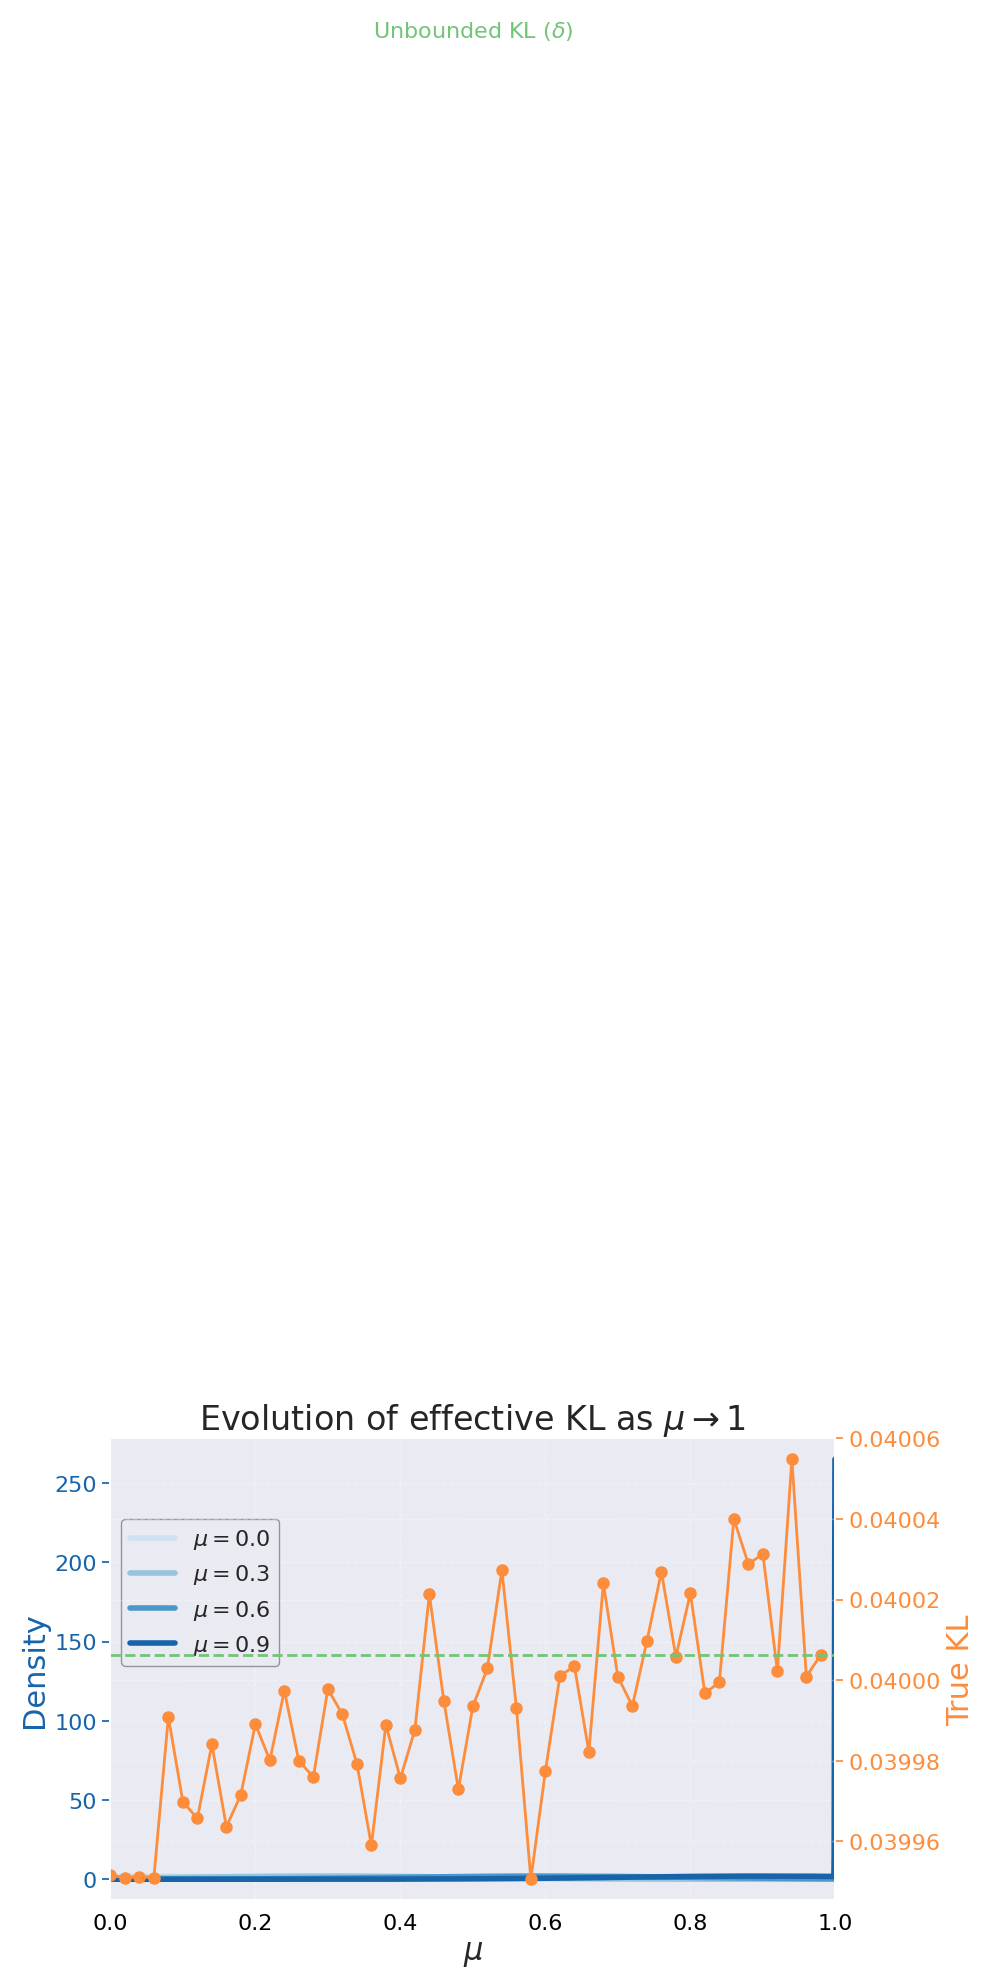

In [28]:
from matplotlib.lines import Line2D

# Create figure with a proper aspect ratio and make sure it's respected
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.85)  # Make room for the second y-axis

num_curves = len(bins)
blue_palette = sns.color_palette("Blues", num_curves)

for i, (bin_centers, h1_hist, h2_hist) in enumerate(zip(bins, hist1, hist2)):
    pdf_color = blue_palette[i]
    ax1.fill_between(bin_centers, h1_hist, color=pdf_color, alpha=0.3)
    ax1.plot(bin_centers, h1_hist, color=pdf_color, lw=4)

ax1.set_xlabel('$\mu$', fontsize=22)
ax1.set_ylabel('Density', color=blue_palette[-1], fontsize=22)
ax1.set_title('Evolution of effective KL as $\mu \\to 1$', fontsize=24)
ax1.tick_params(axis='x', colors='black', labelsize=16)
ax1.tick_params(axis='y', colors=blue_palette[-1], labelsize=16)
ax1.set_xlim(0, 1)  # Restrict x-axis to [0, 1]

kl_color = sns.color_palette("Oranges", 1)[0]
ax2 = ax1.twinx()
ax2.plot(means[:-1], ratios, marker='o', lw=2, color=kl_color)
ax2.set_ylabel('True KL', color=kl_color, fontsize=22)
ax2.tick_params(axis='y', colors=kl_color, labelsize=16)

line_color = sns.color_palette("Greens", 1)[0]

_, _, _, kl_ref = compute_kl_divergence(data_bounded, data_bounded2, plot=False)
ax2.axhline(kl_ref, color=line_color, linestyle='--', lw=2)
x_mid = means[:-1][len(means[:-1]) // 2]
# Position the text ABOVE the line for better visibility
ax2.text(x_mid, kl_ref*1.01, "Unbounded KL ($\\delta$)", color=line_color, ha='center', va='bottom', fontsize=16)

# Add a legend for the blue curves with better positioning
legend_elements = []
for i, val in enumerate([0.0, 0.3, 0.6, 0.9]):
    legend_elements.append(Line2D([0], [0], color=blue_palette[i], lw=4, 
                                 label=f'$\mu = {val}$'))
ax1.legend(handles=legend_elements, loc='upper left', fontsize=16, bbox_to_anchor=(0.0, 0.85))

# Ensure figure has correct aspect ratio
plt.tight_layout()
plt.savefig("./plots/bound/histogram_combined.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [20]:
import numpy as np

# Generate samples from two Gaussians
n_samples = 100000
mean1, std1 = 0.0, 1.0
mean2, std2 = 0.5, 1.0

samples1 = np.random.normal(mean1, std1, n_samples)
samples2 = np.random.normal(mean2, std2, n_samples)

# Compute TV distance between the two sample sets
def compute_tv_distance(p_samples, q_samples, n_bins=100):
    min_val = min(p_samples.min(), q_samples.min())
    max_val = max(p_samples.max(), q_samples.max())
    bins = np.linspace(min_val, max_val, n_bins + 1)
    p_hist, _ = np.histogram(p_samples, bins=bins, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bins, density=True)
    print(p_hist)
    # The multiplication by (bins[1] - bins[0]) converts the sum over histogram bin differences
    # (which are densities) into a sum over probability mass, matching the definition of TV distance
    # for continuous distributions approximated by histograms.
    tv = 0.5 * np.sum(np.abs(p_hist - q_hist)) * (bins[1] - bins[0])
    return tv

tv_distance = compute_tv_distance(samples1, samples2)
print(f"Total Variation (TV) distance between the two Gaussians: {tv_distance:.4f}")



[1.05976873e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.11953745e-04 1.05976873e-04 1.05976873e-04 3.17930618e-04
 0.00000000e+00 7.41838108e-04 8.47814981e-04 7.41838108e-04
 1.27172247e-03 1.27172247e-03 2.86137556e-03 2.11953745e-03
 3.81516741e-03 4.76895927e-03 7.84228857e-03 9.11401104e-03
 1.27172247e-02 1.50487159e-02 1.75921609e-02 2.61762875e-02
 3.09452468e-02 3.60321367e-02 4.20728184e-02 6.06187711e-02
 6.82491060e-02 7.93766776e-02 9.50612547e-02 1.09686063e-01
 1.26748340e-01 1.48791529e-01 1.70092881e-01 1.96375145e-01
 2.14815121e-01 2.35692565e-01 2.53814610e-01 2.83488134e-01
 3.02457994e-01 3.17506710e-01 3.43577021e-01 3.56400223e-01
 3.68587563e-01 3.80562950e-01 3.96989365e-01 3.95293735e-01
 3.99744763e-01 4.02076255e-01 3.81728695e-01 3.84378117e-01
 3.64984349e-01 3.49617703e-01 3.41669437e-01 3.15281196e-01
 2.95357544e-01 2.75115961e-01 2.52118980e-01 2.29016022e-01
 2.11741791e-01 1.85459527e-01 1.74437932e-01 1.48579575e-01
 1.37875911e-01 1.109577

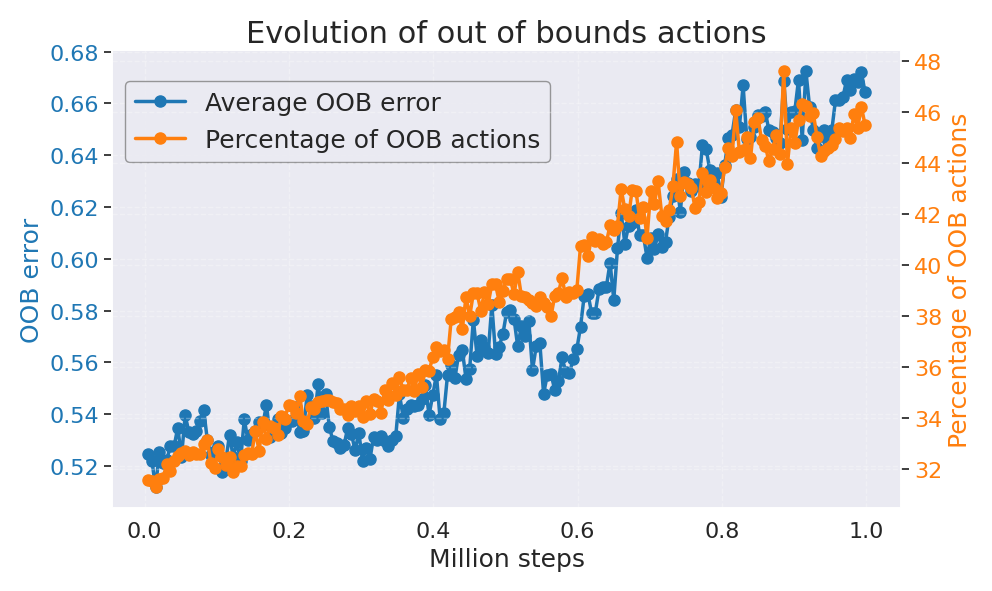

In [29]:
import pandas as pd
import wandb
import os


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
project_name = "PPO_OUTBOUND"
runs = api.runs(entity + "/" + project_name)

# Select one run from the list
run = runs[0]

# Retrieve the run's history containing the necessary metrics
history = run.history(samples=1000000).dropna(subset=["training/out_of_bound_percentage"])


# Create a single figure
fig, ax1 = plt.subplots()

# Plot OOB error on the first y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Million steps')
ax1.set_ylabel('OOB error', color=color1)
ax1.plot(history["_step"]/1e6, history["OOB_error"], marker='o', color=color1, label="Average OOB error")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x')

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Percentage of OOB actions', color=color2)
ax2.plot(history["_step"]/1e6, history["training/out_of_bound_percentage"], marker='o', color=color2, label="Percentage of OOB actions")
ax2.tick_params(axis='y', labelcolor=color2)

# Add title
plt.title("Evolution of out of bounds actions")

# Add legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.0, 0.96))

plt.tight_layout()
plt.savefig("./plots/bound/error.pdf", format="pdf", bbox_inches="tight")  
plt.show()
